# Triangular rearrangement between two silhouettes

This notebook generates `fig:monge-triangular-rearrangement`.  It illustrates the two-dimensional Knothe--Rosenblatt construction on the same cat and heart silhouettes used in `fig:monge-shape-mccann-interpolation`.  This path is not the quadratic Wasserstein geodesic.  It is axis-wise:
$$
(x,y) \longmapsto (T_1(x),y)
\quad\hbox{then}\quad
(T_1(x),y) \longmapsto (T_1(x),T_2(x,y)).
$$
The computation is histogram-based.  The silhouettes are converted to probability images, the horizontal marginal is transported by a dense one-dimensional quantile quadrature, and the vertical conditionals are then transported column by column.  The seven exported panels are source, two horizontal intermediate images, the pivot after all horizontal transport, two vertical intermediate images, and target.


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.parent if candidate.name == "notebooks-figures" else candidate
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import gaussian_filter

from figure_style import figure_dir, interp_color, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
rng = np.random.default_rng(20240612)
ASSETS = ROOT / "notebooks-figures" / "assets"


## From silhouettes to probability images

The input images are converted to smooth probability histograms on a common square grid.  The small left/right offset is the same visual convention as the McCann cat-to-heart interpolation figure.


In [2]:
NAME = "monge-triangular-rearrangement"
OUT = figure_dir(NAME)
GRID_LIM = 1.34
BINS = 220
INPUT_SMOOTHING = 1.05
DISPLAY_SMOOTHING = (0.9, 2.35)  # (vertical, horizontal) pixel smoothing for display only
SATURATION_PERCENTILE = 96.0
N_HORIZONTAL_RANKS = 18000
N_VERTICAL_RANKS = 1400
EPS = 1e-14


def load_shape_points(path):
    """Return normalized point coordinates sampled from a dark silhouette."""
    img = Image.open(path).convert("RGBA")
    arr = np.asarray(img, dtype=float) / 255.0
    rgb = arr[..., :3]
    alpha = arr[..., 3]
    luminance = rgb.mean(axis=2)
    mask = (alpha > 0.25) & (luminance < 0.65)
    ys, xs = np.nonzero(mask)
    pts = np.column_stack([xs, -ys]).astype(float)
    pts += rng.uniform(-0.45, 0.45, size=pts.shape)
    lo = pts.min(axis=0)
    hi = pts.max(axis=0)
    pts = 2 * (pts - lo) / (hi - lo).max() - 1
    pts -= pts.mean(axis=0, keepdims=True)
    return pts


def points_to_density(points, *, bins=BINS, grid_lim=GRID_LIM, sigma=INPUT_SMOOTHING):
    H, xedges, yedges = np.histogram2d(
        points[:, 0],
        points[:, 1],
        bins=bins,
        range=[[-grid_lim, grid_lim], [-grid_lim, grid_lim]],
    )
    H = gaussian_filter(H.T, sigma=sigma, mode="constant")
    H = np.maximum(H, 0)
    H /= H.sum()
    x = 0.5 * (xedges[:-1] + xedges[1:])
    y = 0.5 * (yedges[:-1] + yedges[1:])
    return H, x, y

cat_pts = load_shape_points(ASSETS / "cat.png")
heart_pts = load_shape_points(ASSETS / "heart.jpg")
cat_pts[:, 0] -= 0.18
heart_pts[:, 0] += 0.18
center = np.vstack([cat_pts, heart_pts]).mean(axis=0)
cat_pts -= center
heart_pts -= center

alpha, xgrid, ygrid = points_to_density(cat_pts)
beta, _, _ = points_to_density(heart_pts)
dx = float(xgrid[1] - xgrid[0])
dy = float(ygrid[1] - ygrid[0])


## Quantile maps and conservative deposition

A one-dimensional monotone rearrangement is represented by quantile functions.  To avoid pixel-level striping, the horizontal step is rendered from dense rank samples
$$
x_t(r)=(1-t)Q_\alpha^x(r)+tQ_\beta^x(r),
$$
carrying the source vertical conditional at the corresponding source quantile.  The vertical step uses the same idea independently in each pivot column.


In [3]:
def cell_edges(grid):
    step = float(grid[1] - grid[0])
    return np.concatenate([[grid[0] - step / 2], grid[:-1] + step / 2, [grid[-1] + step / 2]])


def quantile_from_hist(weights, grid, ranks):
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    if total <= EPS:
        return np.full_like(ranks, grid[len(grid) // 2], dtype=float)
    cdf = np.concatenate([[0.0], np.cumsum(weights / total)])
    return np.interp(ranks, cdf, cell_edges(grid))


def conditional_columns(density, marginal):
    cond = np.zeros_like(density)
    active = marginal > EPS
    cond[:, active] = density[:, active] / marginal[active][None, :]
    return cond


def interpolate_column_profiles(columns, x_positions):
    """Linear interpolation of vertical profiles indexed by horizontal position."""
    u = np.clip((x_positions - xgrid[0]) / dx, 0, BINS - 1 - 1e-12)
    i0 = np.floor(u).astype(int)
    w = u - i0
    profiles = (1 - w)[None, :] * columns[:, i0] + w[None, :] * columns[:, i0 + 1]
    masses = profiles.sum(axis=0)
    profiles[:, masses > EPS] /= masses[masses > EPS][None, :]
    return profiles


def deposit_profiles_in_x(profiles, x_positions, masses):
    H = np.zeros((BINS, BINS), dtype=float)
    u = np.clip((x_positions - xgrid[0]) / dx, 0, BINS - 1 - 1e-12)
    i0 = np.floor(u).astype(int)
    w = u - i0
    weighted_profiles = profiles * masses[None, :]
    np.add.at(H, (slice(None), i0), weighted_profiles * (1 - w)[None, :])
    np.add.at(H, (slice(None), i0 + 1), weighted_profiles * w[None, :])
    return H


def deposit_points_in_y(y_positions, masses):
    col = np.zeros(BINS, dtype=float)
    u = np.clip((y_positions - ygrid[0]) / dy, 0, BINS - 1 - 1e-12)
    j0 = np.floor(u).astype(int)
    w = u - j0
    np.add.at(col, j0, masses * (1 - w))
    np.add.at(col, j0 + 1, masses * w)
    return col

mx_alpha = alpha.sum(axis=0)
mx_beta = beta.sum(axis=0)
cond_alpha = conditional_columns(alpha, mx_alpha)

ranks_x = (np.arange(N_HORIZONTAL_RANKS) + 0.5) / N_HORIZONTAL_RANKS
qx_alpha = quantile_from_hist(mx_alpha, xgrid, ranks_x)
qx_beta = quantile_from_hist(mx_beta, xgrid, ranks_x)
profiles_alpha = interpolate_column_profiles(cond_alpha, qx_alpha)
rank_masses_x = np.full_like(ranks_x, 1.0 / len(ranks_x), dtype=float)


def normalize_columns_to_marginal(H, target_marginal):
    H = np.maximum(H, 0).copy()
    for j, target in enumerate(target_marginal):
        current = H[:, j].sum()
        if current > EPS:
            H[:, j] *= target / current
        elif target > EPS:
            # This should rarely happen; use the target conditional as a safe fallback.
            H[:, j] = target * beta[:, j] / max(beta[:, j].sum(), EPS)
    H /= H.sum()
    return H


def horizontal_frame(t):
    x_t = (1 - t) * qx_alpha + t * qx_beta
    H = deposit_profiles_in_x(profiles_alpha, x_t, rank_masses_x)
    H /= H.sum()
    return H

pivot = normalize_columns_to_marginal(horizontal_frame(1.0), mx_beta)
cond_pivot = conditional_columns(pivot, mx_beta)
cond_beta = conditional_columns(beta, mx_beta)

print(f"pivot x-marginal error: {np.abs(pivot.sum(axis=0) - mx_beta).sum():.2e}")
print(f"horizontal rank samples: {len(ranks_x)}")
print(f"vertical rank samples per active column: {N_VERTICAL_RANKS}")


pivot x-marginal error: 2.51e-16
horizontal rank samples: 18000
vertical rank samples per active column: 1400


## Seven-panel axis-wise interpolation

The first stage changes only the horizontal marginal.  The pivot is then column-normalized to have exactly the target horizontal marginal.  The second stage leaves columns fixed and interpolates the vertical conditional quantiles in each column.  The displayed images use a common saturation level so color intensity is comparable across the row.  A mild anisotropic smoothing is applied only at display time, after the conservative histogram construction, to suppress grid artifacts.


In [4]:
ranks_y = (np.arange(N_VERTICAL_RANKS) + 0.5) / N_VERTICAL_RANKS


def vertical_frame(t):
    H = np.zeros_like(alpha)
    for j, mass in enumerate(mx_beta):
        if mass <= EPS:
            continue
        y0 = quantile_from_hist(cond_pivot[:, j], ygrid, ranks_y)
        y1 = quantile_from_hist(cond_beta[:, j], ygrid, ranks_y)
        y_t = (1 - t) * y0 + t * y1
        H[:, j] = deposit_points_in_y(y_t, np.full_like(ranks_y, mass / len(ranks_y)))
    H /= H.sum()
    return H

raw_frames = [
    alpha,
    horizontal_frame(1 / 3),
    horizontal_frame(2 / 3),
    pivot,
    vertical_frame(1 / 3),
    vertical_frame(2 / 3),
    beta,
]
frame_names = [
    "stage-01-source",
    "stage-02-horizontal-033",
    "stage-03-horizontal-067",
    "stage-04-pivot",
    "stage-05-vertical-033",
    "stage-06-vertical-067",
    "stage-07-target",
]
frame_colors = [interp_color(k / 6) for k in range(7)]

render_frames = [gaussian_filter(H, sigma=DISPLAY_SMOOTHING, mode="constant") for H in raw_frames]
positive_values = np.concatenate([H[H > 0] for H in render_frames])
global_scale = np.percentile(positive_values, SATURATION_PERCENTILE)
extent = (xgrid[0], xgrid[-1], ygrid[0], ygrid[-1])


def color_density_image(H, color, scale=global_scale):
    color = np.asarray(color, dtype=float)
    v = np.clip(H / max(scale, EPS), 0, 1)
    return (1 - v[..., None]) * np.ones((*H.shape, 3)) + v[..., None] * color

for name, H, color in zip(frame_names, render_frames, frame_colors):
    fig, ax = plt.subplots(figsize=(1.48, 1.48))
    ax.imshow(color_density_image(H, color), extent=extent, origin="lower", interpolation="bicubic")
    ax.set_xlim(-GRID_LIM, GRID_LIM)
    ax.set_ylim(-GRID_LIM, GRID_LIM)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, OUT / f"{name}.pdf", pad_inches=0.006)
    plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


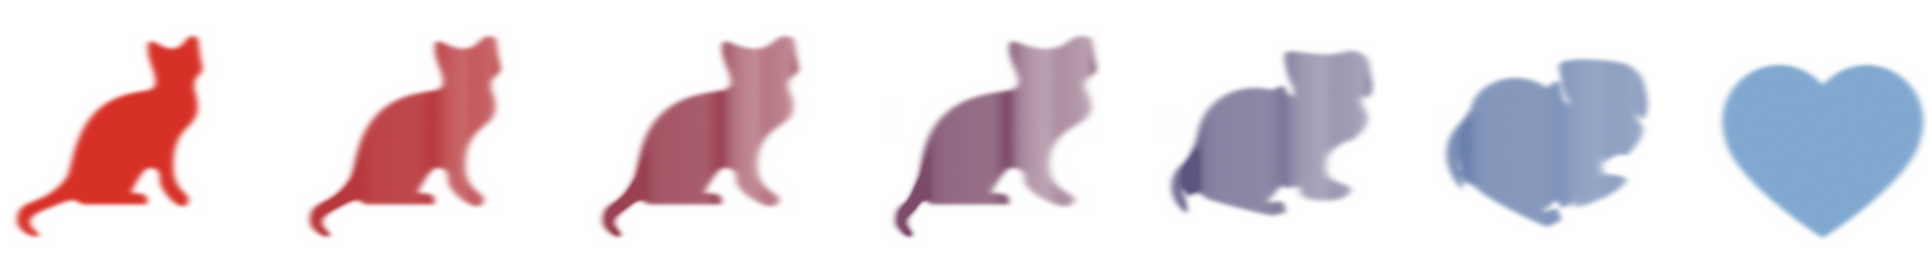

In [5]:
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)
thumb_path = thumb_dir / f"{NAME}.png"

fig, axes = plt.subplots(1, 7, figsize=(10.7, 1.5))
for ax, H, color in zip(axes, render_frames, frame_colors):
    ax.imshow(color_density_image(H, color), extent=extent, origin="lower", interpolation="bicubic")
    ax.set_xlim(-GRID_LIM, GRID_LIM)
    ax.set_ylim(-GRID_LIM, GRID_LIM)
    ax.set_aspect("equal")
    remove_axes(ax)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.018)
fig.savefig(thumb_path, dpi=180, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

from IPython.display import Image as IPImage, display
_thumb = Path("thumbnails/monge-triangular-rearrangement.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/monge-triangular-rearrangement.png")
display(IPImage(filename=str(_thumb)))
